# TTT Block Size Comparison
Comparing gradients across three methods:
1. **Surrogate (no blocks)**: Pure surrogate approximation, token-by-token
2. **Surrogate (block_size=16)**: Exact within-block + surrogate inter-block
3. **True backprop**: Exact gradients (reference)

In [1]:
import os
os.environ['TF_GPU_ALLOCATOR']='cuda_malloc_async'

import sys

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from flax import nnx
from flax.nnx import rnglib as rng

sys.path.insert(0, '../../..')

from ueaj.model.ttt import TTTModel
from ueaj.model import GMLP

W0107 21:53:25.277348  105876 cuda_executor.cc:1802] GPU interconnect information not available: INTERNAL: NVML doesn't support extracting fabric info or NVLink is not used by the device.
W0107 21:53:25.281772  105467 cuda_executor.cc:1802] GPU interconnect information not available: INTERNAL: NVML doesn't support extracting fabric info or NVLink is not used by the device.


In [2]:
# Config
model_d, hidden_d = 512, 512
batch_size, seq_len = 1, 256
block_size = 16
seed = 42

def sample_distribution(key, shape):
    b = 3  # b=3 gives variance=1 with no scaling needed!
    key1, key2 = jax.random.split(key)
    samples = (jax.random.pareto(key1, b, shape) - 1) * jax.random.rademacher(key2, shape)
    return samples

In [3]:
# Create three models with different gradient strategies
model_surr_noblock = TTTModel(model_d, hidden_d, q_heads=1, module=GMLP, surrogate=True, block_size=None, rngs=rng.Rngs(seed))
model_surr_block = TTTModel(model_d, hidden_d, q_heads=1, module=GMLP, surrogate=True, block_size=block_size, rngs=rng.Rngs(seed))
model_true = TTTModel(model_d, hidden_d, q_heads=1, module=GMLP, surrogate=False, rngs=rng.Rngs(seed))

# Generate k, v, q directly
key = jax.random.PRNGKey(300)
k_key, v_key, q_key = jax.random.split(key, 3)
k = sample_distribution(k_key, (batch_size, seq_len, hidden_d))
v = sample_distribution(v_key, (batch_size, seq_len, hidden_d))
q = sample_distribution(q_key, (batch_size, seq_len, 1, hidden_d))

print(f"k shape: {k.shape}, v shape: {v.shape}, q shape: {q.shape}")
print(f"seq_len: {seq_len}, block_size: {block_size}, num_blocks: {seq_len // block_size}")

k shape: (1, 256, 512), v shape: (1, 256, 512), q shape: (1, 256, 1, 512)
seq_len: 256, block_size: 16, num_blocks: 16


In [4]:
@jax.jit
def compute_grads(model, k, v, q, grad_output):
    """Compute gradients w.r.t. k, v, q and init_state using VJP."""
    init_state = nnx.state(model.inner_module)

    def forward(k, v, q, state):
        output, final_state = model.ttt_fn(k, v, q, state)
        return output, final_state

    grad_final_state = jax.tree.map(
        lambda v: jnp.zeros_like(v)[None, ...], init_state)

    (output, final_state), vjp_fn = jax.vjp(forward, k, v, q, init_state)
    grad_k, grad_v, grad_q, grad_init_state = vjp_fn((grad_output, grad_final_state))
    return grad_k, grad_v, grad_q, grad_init_state, output


def cosine_similarity_per_token(grad_test, grad_ref):
    """Compute cosine similarity per token position vs reference."""
    dot_product = jnp.sum(grad_test * grad_ref, axis=-1)
    norm_test = jnp.linalg.norm(grad_test, axis=-1)
    norm_ref = jnp.linalg.norm(grad_ref, axis=-1)
    cosine_sim = dot_product / (norm_test * norm_ref + 1e-8)
    # Handle extra dimensions (batch, seq, ...)
    while cosine_sim.ndim > 1:
        cosine_sim = cosine_sim.mean(axis=0)
    return cosine_sim


def rms_error_per_token(grad_test, grad_ref):
    """Compute RMS error per token position."""
    diff = grad_test - grad_ref
    rms = jnp.sqrt(jnp.mean(diff ** 2, axis=-1))
    while rms.ndim > 1:
        rms = rms.mean(axis=0)
    return rms

In [5]:
# Random output gradient
grad_output = jax.random.normal(jax.random.PRNGKey(456), (batch_size, seq_len, 1, hidden_d))

# Compute gradients for all three methods
print("Computing gradients...")
gk_noblock, gv_noblock, gq_noblock, gs_noblock, _ = compute_grads(model_surr_noblock, k, v, q, grad_output)
gk_block, gv_block, gq_block, gs_block, _ = compute_grads(model_surr_block, k, v, q, grad_output)
gk_true, gv_true, gq_true, gs_true, _ = compute_grads(model_true, k, v, q, grad_output)
print("Done!")

Computing gradients...
Done!


In [6]:
# Compute cosine similarities vs TRUE gradient
cos_k_noblock = cosine_similarity_per_token(gk_noblock, gk_true)
cos_k_block = cosine_similarity_per_token(gk_block, gk_true)

cos_v_noblock = cosine_similarity_per_token(gv_noblock, gv_true)
cos_v_block = cosine_similarity_per_token(gv_block, gv_true)

cos_q_noblock = cosine_similarity_per_token(gq_noblock.squeeze(2), gq_true.squeeze(2))
cos_q_block = cosine_similarity_per_token(gq_block.squeeze(2), gq_true.squeeze(2))

print(f"Cosine similarity to TRUE gradient:")
print(f"  dk (no block): [{float(cos_k_noblock.min()):.4f}, {float(cos_k_noblock.max()):.4f}], mean={float(cos_k_noblock.mean()):.4f}")
print(f"  dk (block={block_size}): [{float(cos_k_block.min()):.4f}, {float(cos_k_block.max()):.4f}], mean={float(cos_k_block.mean()):.4f}")
print()
print(f"  dv (no block): [{float(cos_v_noblock.min()):.4f}, {float(cos_v_noblock.max()):.4f}], mean={float(cos_v_noblock.mean()):.4f}")
print(f"  dv (block={block_size}): [{float(cos_v_block.min()):.4f}, {float(cos_v_block.max()):.4f}], mean={float(cos_v_block.mean()):.4f}")

Cosine similarity to TRUE gradient:
  dk (no block): [0.7140, 0.9949], mean=0.9374
  dk (block=16): [0.8541, 0.9999], mean=0.9523

  dv (no block): [0.4253, 0.9977], mean=0.9415
  dv (block=16): [0.7845, 0.9999], mean=0.9555


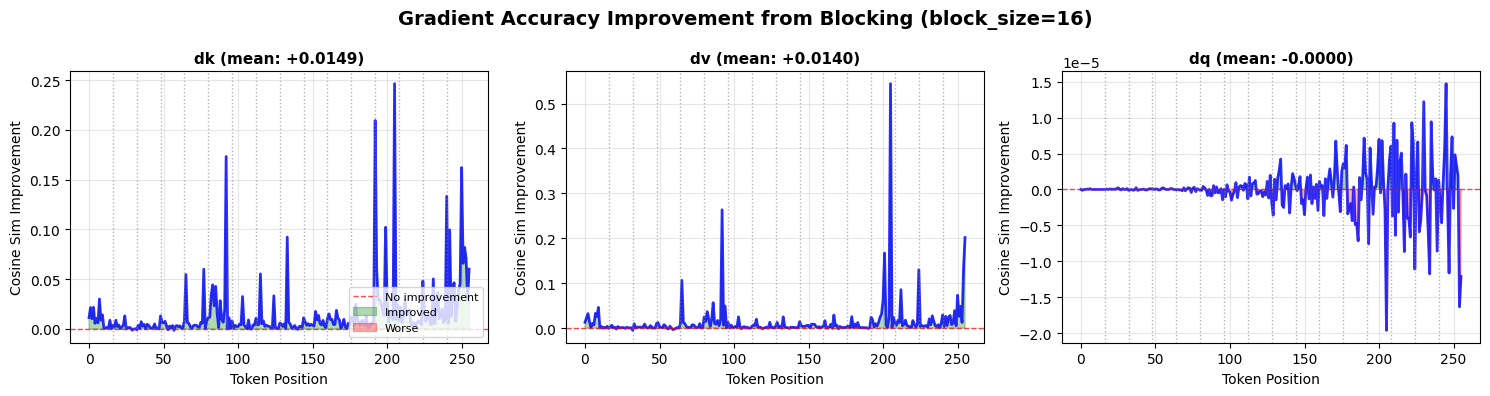

In [7]:
# Plot the IMPROVEMENT from blocking: cos_sim(block, true) - cos_sim(noblock, true)
from matplotlib.lines import Line2D

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle(f'Gradient Accuracy Improvement from Blocking (block_size={block_size})', fontsize=14, fontweight='bold')

tokens = np.arange(seq_len)

# Helper to add block boundary lines
def add_block_lines(ax):
    for pos in range(block_size, seq_len, block_size):
        ax.axvline(x=pos, color='gray', linestyle=':', linewidth=1, alpha=0.6)

# Compute improvement: cos_sim(block, true) - cos_sim(noblock, true)
diff_k = cos_k_block - cos_k_noblock
diff_v = cos_v_block - cos_v_noblock
diff_q = cos_q_block - cos_q_noblock

# dk improvement
ax1 = axes[0]
ax1.plot(tokens, diff_k, 'b-', linewidth=2, alpha=0.8)
ax1.axhline(y=0, color='r', linestyle='--', linewidth=1, alpha=0.7, label='No improvement')
ax1.fill_between(tokens, 0, diff_k, where=(diff_k > 0), alpha=0.3, color='green', label='Improved')
ax1.fill_between(tokens, 0, diff_k, where=(diff_k < 0), alpha=0.3, color='red', label='Worse')
add_block_lines(ax1)
ax1.set_xlabel('Token Position', fontsize=10)
ax1.set_ylabel('Cosine Sim Improvement', fontsize=10)
ax1.set_title(f'dk (mean: {float(diff_k.mean()):+.4f})', fontsize=11, fontweight='bold')
ax1.legend(fontsize=8, loc='lower right')
ax1.grid(True, alpha=0.3)

# dv improvement
ax2 = axes[1]
ax2.plot(tokens, diff_v, 'b-', linewidth=2, alpha=0.8)
ax2.axhline(y=0, color='r', linestyle='--', linewidth=1, alpha=0.7)
ax2.fill_between(tokens, 0, diff_v, where=(diff_v > 0), alpha=0.3, color='green')
ax2.fill_between(tokens, 0, diff_v, where=(diff_v < 0), alpha=0.3, color='red')
add_block_lines(ax2)
ax2.set_xlabel('Token Position', fontsize=10)
ax2.set_ylabel('Cosine Sim Improvement', fontsize=10)
ax2.set_title(f'dv (mean: {float(diff_v.mean()):+.4f})', fontsize=11, fontweight='bold')
ax2.grid(True, alpha=0.3)

# dq improvement
ax3 = axes[2]
ax3.plot(tokens, diff_q, 'b-', linewidth=2, alpha=0.8)
ax3.axhline(y=0, color='r', linestyle='--', linewidth=1, alpha=0.7)
ax3.fill_between(tokens, 0, diff_q, where=(diff_q > 0), alpha=0.3, color='green')
ax3.fill_between(tokens, 0, diff_q, where=(diff_q < 0), alpha=0.3, color='red')
add_block_lines(ax3)
ax3.set_xlabel('Token Position', fontsize=10)
ax3.set_ylabel('Cosine Sim Improvement', fontsize=10)
ax3.set_title(f'dq (mean: {float(diff_q.mean()):+.4f})', fontsize=11, fontweight='bold')
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('ttt_block_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

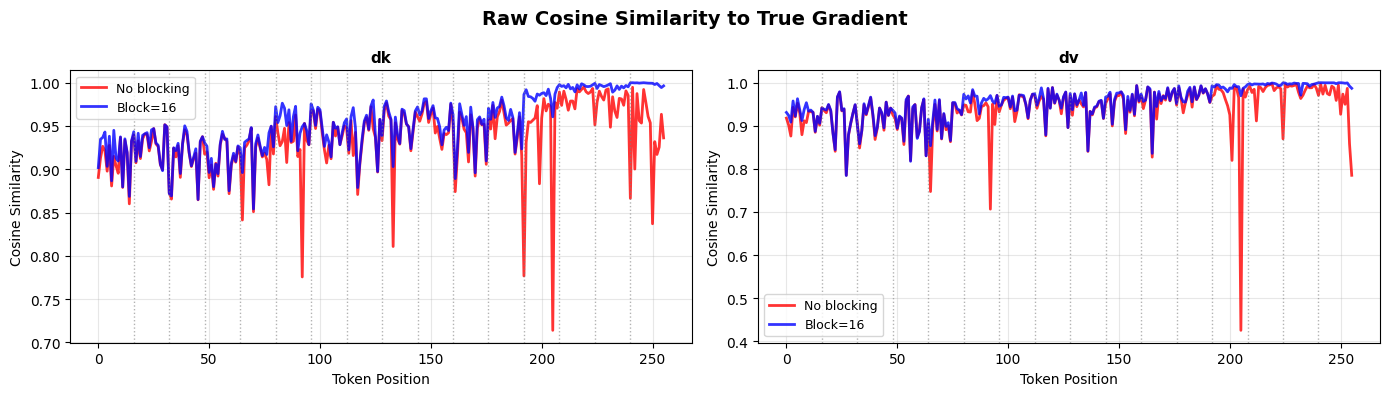

In [8]:
# Also show the raw cosine similarities for reference
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Raw Cosine Similarity to True Gradient', fontsize=14, fontweight='bold')

# dk 
ax1 = axes[0]
ax1.plot(tokens, cos_k_noblock, 'r-', linewidth=2, label='No blocking', alpha=0.8)
ax1.plot(tokens, cos_k_block, 'b-', linewidth=2, label=f'Block={block_size}', alpha=0.8)
add_block_lines(ax1)
ax1.set_xlabel('Token Position', fontsize=10)
ax1.set_ylabel('Cosine Similarity', fontsize=10)
ax1.set_title('dk', fontsize=11, fontweight='bold')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# dv
ax2 = axes[1]
ax2.plot(tokens, cos_v_noblock, 'r-', linewidth=2, label='No blocking', alpha=0.8)
ax2.plot(tokens, cos_v_block, 'b-', linewidth=2, label=f'Block={block_size}', alpha=0.8)
add_block_lines(ax2)
ax2.set_xlabel('Token Position', fontsize=10)
ax2.set_ylabel('Cosine Similarity', fontsize=10)
ax2.set_title('dv', fontsize=11, fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()